# Chapter 7: Cross-Validation in Finance

Building on Chapters 2-6: this chapter implements `PurgedKFold` and `cvScore`
(AFML snippets 7.3 and 7.4), the cross-validation scheme designed specifically
for financial ML, and applies it to the real BTC/TUSD triple-barrier labels
from Chapters 3-5.

## Why standard k-fold CV leaks on financial data

Standard k-fold cross-validation assumes each observation is independent and
identically distributed (IID). Randomly assign observations to folds, and
whatever ends up in "train" tells you nothing about what's in "test."

Financial labels break that assumption. A triple-barrier label isn't a single
point in time -- it's an **interval** `[t0, t1]`: the observation starts at
`t0` and its outcome isn't known until the price touches a barrier or the
vertical deadline expires at `t1`. Because trades happen close together in
time, **neighboring observations' label intervals overlap**. If a naive
random k-fold split puts overlapping-in-time observations on both sides of
the train/test line, the model is effectively training on information that
leaks into its own test set through that overlap -- the CV score comes back
optimistic, and you can't trust it to reflect real out-of-sample performance.

`PurgedKFold` fixes this two ways:

1. **Purging** -- drop any training observation whose label interval
   overlaps the test set's time range.
2. **Embargo** -- drop a further slice of training observations immediately
   *after* the test set, because financial time series carry serial
   correlation past the strict label window. A purged-clean label can still
   be informationally leaked by autocorrelation in the underlying returns.


In [1]:
# AFML_ROOT: EDIT THIS to match your local workspace path
AFML_ROOT = r'C:\ws\AFML'

import os
import sys
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier

sys.path.insert(0, os.path.join(AFML_ROOT, 'ch07', 'cross_validation'))
from purged_kfold import PurgedKFold, cvScore

INPUT_DIR = os.path.join(AFML_ROOT, 'input_data')
pd.set_option('display.max_columns', None)


## Loading the Chapter 3-5 artifacts

Ch07's training table is assembled from three upstream chapters, all
already index-aligned to the 88 triple-barrier events:

| Source | Column(s) used | Role |
|---|---|---|
| `ch05_features.pkl` | `fracdiff` | **X** -- the feature |
| `ch03_events.pkl` | `bin` | **y** -- the label |
| `ch04_weights.pkl` | `w` | **sample_weight** -- trust weight |
| `ch03_events.pkl` | `t1` | **purging metadata** -- never a model input |


In [2]:
ch03 = pd.read_pickle(os.path.join(INPUT_DIR, 'ch03_events.pkl'))
ch04 = pd.read_pickle(os.path.join(INPUT_DIR, 'ch04_weights.pkl'))
ch05 = pd.read_pickle(os.path.join(INPUT_DIR, 'ch05_features.pkl'))

print('ch03_events:', ch03.shape, list(ch03.columns))
print('ch04_weights:', ch04.shape, list(ch04.columns))
print('ch05_features:', ch05.shape, list(ch05.columns))
print('\nch03 index equals ch04 index:', ch03.index.equals(ch04.index))


ch03_events: (88, 4) ['t1', 'trgt', 'ret', 'bin']
ch04_weights: (88, 2) ['w', 'tw']
ch05_features: (239, 2) ['close', 'fracdiff']

ch03 index equals ch04 index: True


In [3]:
# Build the X/y/w/t1 training table.
# ch05_features has 239 rows (raw bars); .loc reindexes down to exactly the
# 88 event timestamps -- an exact reindex, no as-of merge needed (verified
# in the Ch05 handoff: all 88 Ch03 events land on a feature bar).
X = ch05.loc[ch03.index][['fracdiff']]
y = ch03['bin']
w = ch04['w']
t1 = ch03['t1']

assert X.index.equals(y.index) and X.index.equals(w.index) and X.index.equals(t1.index), \
    'X/y/w/t1 must share an identical index before going anywhere near PurgedKFold'

table = pd.concat([X, y.rename('bin'), w.rename('w'), t1.rename('t1')], axis=1)
print('Training table:', table.shape)
table.head()


Training table: (88, 4)


,fracdiff,bin,w,t1
2026-03-02 13:05:06.160435,5.963681,-1.0,2.274895,2026-03-02 13:50:21.805687
2026-03-02 15:30:49.837102,6.003580,1.0,7.344949,2026-03-02 16:46:56.199924
2026-03-02 16:46:56.199924,6.017582,-1.0,0.341358,2026-03-02 19:00:58.984721
2026-03-02 19:00:58.984721,5.993668,-1.0,2.939428,2026-03-03 09:28:01.084240
2026-03-03 03:09:58.655387,5.985434,-1.0,2.212135,2026-03-03 09:28:01.084240


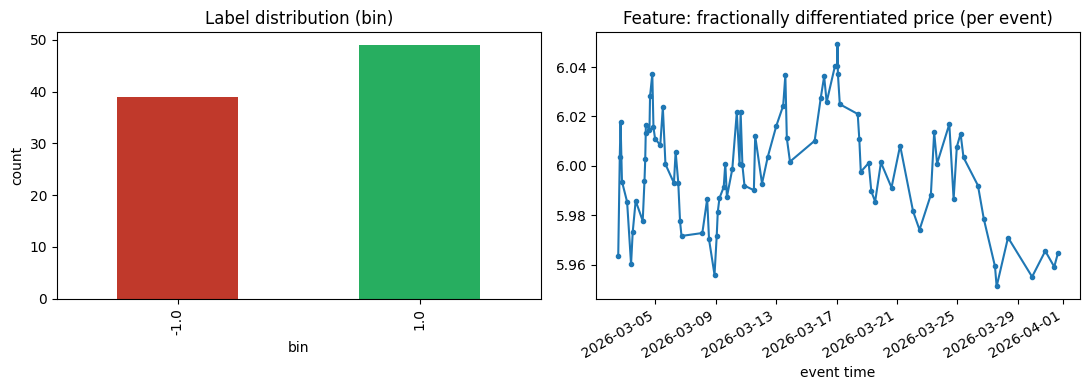

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
y.value_counts().sort_index().plot(kind='bar', ax=axes[0], color=['#c0392b', '#27ae60'])
axes[0].set_title('Label distribution (bin)')
axes[0].set_xlabel('bin')
axes[0].set_ylabel('count')

X['fracdiff'].plot(ax=axes[1], marker='o', markersize=3)
axes[1].set_title('Feature: fractionally differentiated price (per event)')
axes[1].set_xlabel('event time')
plt.tight_layout()
plt.show()


## The math: purge and embargo

For a test fold covering rows `[i, j)`:

- **Embargo size**: `mbrg = int(n_samples * pctEmbargo)`
- **Purge (backward)**: keep training observations whose own label already
  resolved before the test fold starts: `t1[t1.index] <= t0` where
  `t0 = t1.index[i]`.
- **Purge + embargo (forward)**: find `maxT1Idx`, the position where the
  *latest* label among the test observations resolves. Drop all training
  rows from there through `maxT1Idx + mbrg`.

`pctEmbargo` needs to be picked deliberately -- the sklearn default of `0.`
gives *no* embargo. On this 88-row dataset, `int(88 * 0.01) = 0` (1% rounds
to zero), which doesn't cover anything. The Ch05 `fracdiff` feature uses a
10-bar rolling window, so we use **`pctEmbargo ~= 0.12`** to embargo enough
bars to cover that window.


In [5]:
N_SPLITS = 4
PCT_EMBARGO = 0.12

pkf = PurgedKFold(n_splits=N_SPLITS, t1=t1, pctEmbargo=PCT_EMBARGO)

fold_rows = []
for k, (train_idx, test_idx) in enumerate(pkf.split(X)):
    fold_rows.append({
        'fold': k,
        'train_n': len(train_idx),
        'test_n': len(test_idx),
        'train_sum_w': w.iloc[train_idx].sum(),
    })
fold_df = pd.DataFrame(fold_rows).set_index('fold')
fold_df


,train_n,test_n,train_sum_w
fold,,,
0,52,22,39.521565
1,43,22,53.521003
2,42,22,53.428111
3,63,22,67.092523


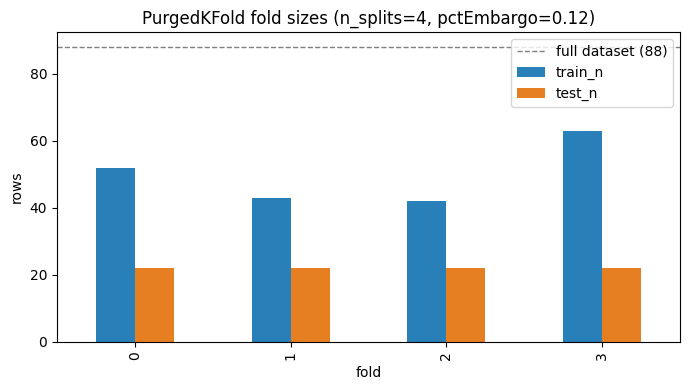

Note: train_n is well below 88 - len(test) in every fold. That gap is
purging + embargo removing observations whose labels overlap the test window.


In [6]:
fig, ax = plt.subplots(figsize=(7, 4))
fold_df[['train_n', 'test_n']].plot(kind='bar', stacked=False, ax=ax,
                                     color=['#2980b9', '#e67e22'])
ax.axhline(len(X), color='gray', linestyle='--', linewidth=1, label='full dataset (88)')
ax.set_title(f'PurgedKFold fold sizes (n_splits={N_SPLITS}, pctEmbargo={PCT_EMBARGO})')
ax.set_ylabel('rows')
ax.legend()
plt.tight_layout()
plt.show()

print('Note: train_n is well below 88 - len(test) in every fold. That gap is')
print('purging + embargo removing observations whose labels overlap the test window.')


## Sanity-checking `PurgedKFold(_BaseKFold)` against sklearn 1.2.2

Before trusting any of the above, the riskiest unknown was whether AFML's
`PurgedKFold` -- which subclasses sklearn's private `_BaseKFold` and
overrides `split()` entirely -- still satisfies that class's contract on
**sklearn 1.2.2** specifically (this repo's pinned version).

This was checked directly against the real 1.2.2 wheel (not assumed from
memory or a different installed version):

- `_BaseKFold.__init__` is `@abstractmethod`, signature
  `(self, n_splits, *, shuffle, random_state)` -- keyword-only `shuffle`/
  `random_state`. `PurgedKFold` overriding `__init__` satisfies this.
- `_BaseKFold.__init__` validates `shuffle` is bool and raises if
  `shuffle=False` with `random_state` set -- inherited for free, confirmed
  it actually fires.
- `get_n_splits()` is inherited unchanged.
- **No version drift** found on any of this between sklearn 1.2.2 and newer
  releases -- this part of sklearn's internals has been stable for years.

The one real bug found wasn't sklearn's: the book's original snippet 7.3
uses `self.t1[test_indices]` -- a **positional** lookup written with
`Series.__getitem__` on a **non-integer** (datetime) index. Pandas silently
supported that via a deprecated fallback through 1.x (with a
`FutureWarning`), but pandas >= 2.0 removed the fallback entirely and turns
it into a hard `KeyError`. Fixed here with explicit `.iloc[test_indices]`,
which is correct on every pandas version, including this repo's pinned
1.5.3.


In [7]:
# Regression check: this must not raise, on any pandas version.
list(pkf.split(X))
print('PurgedKFold.split() runs clean -- no positional-indexing KeyError.')


PurgedKFold.split() runs clean -- no positional-indexing KeyError.


## Scoring: `cvScore`

sklearn's built-in `cross_val_score` doesn't accept a per-fold
`sample_weight` for the *scoring* metric (only for `.fit()`, via
`fit_params`). `cvScore` (AFML snippet 7.4) reimplements the loop manually so
`w` (the Ch04 return-attribution weight) is threaded through **both**
`.fit()` and the score.

Two classifiers, matching the Ch06 -> Ch07 handoff:

- **`RandomForestClassifier(class_weight='balanced_subsample')`** -- handles
  the 39/49 label imbalance.
- **`BaggingClassifier(max_samples=avgU)`** -- the Ch06 mechanism for
  fighting correlated trees from overlapping labels: instead of bootstrapping
  the full training set per tree, draw only `avgU` (~0.2288, from Ch04's
  average uniqueness) as a fraction of it.


In [8]:
clf_rf = RandomForestClassifier(
    n_estimators=100, class_weight='balanced_subsample', random_state=1
)
scores_rf = cvScore(clf_rf, X, y, sample_weight=w, scoring='accuracy',
                     t1=t1, n_splits=N_SPLITS, pctEmbargo=PCT_EMBARGO)

print('RandomForest accuracy per fold:', np.round(scores_rf, 4))
print('Mean:', round(scores_rf.mean(), 4), ' Std:', round(scores_rf.std(), 4))


RandomForest accuracy per fold: [0.459  0.5893 0.7157 0.422 ]
Mean: 0.5465  Std: 0.1158


In [9]:
AVG_U = 0.2288  # from Ch04: mean sample uniqueness

clf_bag = BaggingClassifier(n_estimators=100, max_samples=AVG_U, random_state=1)
scores_bag = cvScore(clf_bag, X, y, sample_weight=w, scoring='neg_log_loss',
                      t1=t1, n_splits=N_SPLITS, pctEmbargo=PCT_EMBARGO)

print('BaggingClassifier(max_samples=avgU) neg_log_loss per fold:', np.round(scores_bag, 4))
print('Mean:', round(scores_bag.mean(), 4), ' Std:', round(scores_bag.std(), 4))


/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_bagging.py:98: UserWarning: Using the fractional value max_samples=0.2288 when the total sum of sample weights is 39.52156503420881 results in a low number (9) of bootstrap samples. We recommend passing `max_samples` as an integer instead.
  warn(


BaggingClassifier(max_samples=avgU) neg_log_loss per fold: [-0.8134 -0.6611 -0.6856 -0.8431]
Mean: -0.7508  Std: 0.0786


### A `max_samples` gotcha worth knowing about

You may see a `UserWarning` about a low bootstrap sample count on the cell
above -- that specific warning is a sklearn-version artifact of whatever
environment ran this notebook last (newer sklearn releases compute the
warning threshold differently). **What matters is your pinned sklearn
1.2.2**, and its actual behavior is simpler and worth understanding
directly:

`BaggingClassifier`'s `max_samples` fraction is computed as
`int(max_samples * n_train_rows)` -- **a fraction of the training fold's row
count, independent of `sample_weight`.** (Later sklearn releases introduced
an alternative "frequency semantics" mode where a float `max_samples` is
instead scaled by `sample_weight.sum()` when weights are passed -- that's
not what happens on 1.2.2.)

Combined with purging shrinking each fold's training set well below the
full 88 rows, `max_samples=0.2288` ends up drawing a genuinely small number
of rows per tree -- worth knowing rather than assuming it always means
"~20 rows" the way it would outside of cross-validation.


In [10]:
for k, (train_idx, test_idx) in enumerate(pkf.split(X)):
    n_train = len(train_idx)
    bootstrap_rows = int(AVG_U * n_train)
    print(f'Fold {k}: train_n={n_train:2d}  ->  BaggingClassifier draws {bootstrap_rows} rows/tree')


Fold 0: train_n=52  ->  BaggingClassifier draws 11 rows/tree
Fold 1: train_n=43  ->  BaggingClassifier draws 9 rows/tree
Fold 2: train_n=42  ->  BaggingClassifier draws 9 rows/tree
Fold 3: train_n=63  ->  BaggingClassifier draws 14 rows/tree


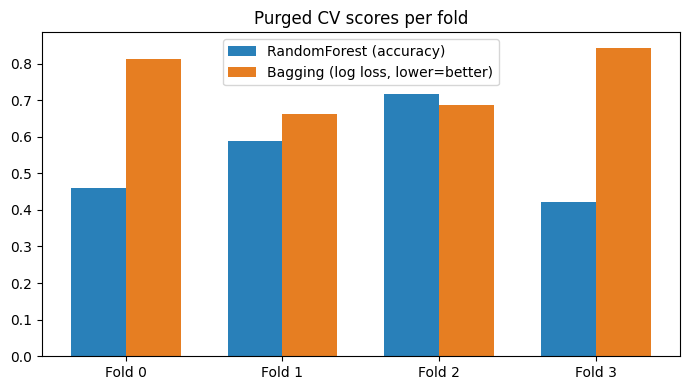

In [11]:
fig, ax = plt.subplots(figsize=(7, 4))
x_pos = np.arange(N_SPLITS)
width = 0.35
ax.bar(x_pos - width/2, scores_rf, width, label='RandomForest (accuracy)', color='#2980b9')
ax.bar(x_pos + width/2, -scores_bag, width, label='Bagging (log loss, lower=better)', color='#e67e22')
ax.set_xticks(x_pos)
ax.set_xticklabels([f'Fold {k}' for k in range(N_SPLITS)])
ax.set_title('Purged CV scores per fold')
ax.legend()
plt.tight_layout()
plt.show()


## Saving Ch07 outputs

Per project convention: final chapter output saves as `.pkl` (source of
truth) + `.csv` (human-readable) into the shared `input_data\` folder.


In [12]:
OUTPUT_TABLE_PATH_PKL = os.path.join(INPUT_DIR, 'ch07_training_table.pkl')
OUTPUT_TABLE_PATH_CSV = os.path.join(INPUT_DIR, 'ch07_training_table.csv')
table.to_pickle(OUTPUT_TABLE_PATH_PKL)
table.to_csv(OUTPUT_TABLE_PATH_CSV)

cv_results = pd.DataFrame({
    'rf_accuracy': scores_rf,
    'bagging_neg_log_loss': scores_bag,
})
cv_results.to_pickle(os.path.join(INPUT_DIR, 'ch07_cv_scores.pkl'))
cv_results.to_csv(os.path.join(INPUT_DIR, 'ch07_cv_scores.csv'))

print('Saved:', OUTPUT_TABLE_PATH_PKL)
print('Saved:', OUTPUT_TABLE_PATH_CSV)
print('Saved ch07_cv_scores.pkl / .csv')
cv_results


Saved: /home/claude/afml_sandbox_root/input_data/ch07_training_table.pkl
Saved: /home/claude/afml_sandbox_root/input_data/ch07_training_table.csv
Saved ch07_cv_scores.pkl / .csv


,rf_accuracy,bagging_neg_log_loss
0,0.459045,-0.813432
1,0.589279,-0.661147
2,0.715720,-0.685583
3,0.421959,-0.843065


## TDD results

`test_purged_kfold.py` -- 16 tests covering the sklearn 1.2.2 abstract-class
contract, purge/embargo correctness (hand-traced against known label
overlaps), the pandas positional-indexing regression, index-alignment
guards, and `cvScore` on both dummy and this chapter's real 88-row data.

```
============================= test session starts ==============================
test_purged_kfold.py::test_purged_kfold_requires_series_t1 PASSED        [  6%]
test_purged_kfold.py::test_purged_kfold_default_pctEmbargo_is_zero_not_none PASSED [ 12%]
test_purged_kfold.py::test_purged_kfold_get_n_splits PASSED              [ 18%]
test_purged_kfold.py::test_purged_kfold_rejects_bad_shuffle_random_state_combo PASSED [ 25%]
test_purged_kfold.py::test_split_rejects_misaligned_index PASSED         [ 31%]
test_purged_kfold.py::test_split_produces_non_overlapping_test_sets PASSED [ 37%]
test_purged_kfold.py::test_split_purges_overlapping_labels PASSED        [ 43%]
test_purged_kfold.py::test_split_keeps_train_obs_resolved_before_test_start PASSED [ 50%]
test_purged_kfold.py::test_split_uses_iloc_not_deprecated_getitem PASSED [ 56%]
test_purged_kfold.py::test_cvscore_requires_t1 PASSED                    [ 62%]
test_purged_kfold.py::test_cvscore_rejects_bad_scoring PASSED            [ 68%]
test_purged_kfold.py::test_cvscore_uniform_weight_default PASSED         [ 75%]
test_purged_kfold.py::test_cvscore_index_mismatch_guard PASSED           [ 81%]
test_purged_kfold.py::test_cvscore_real_data_random_forest PASSED        [ 87%]
test_purged_kfold.py::test_cvscore_real_data_neg_log_loss PASSED         [ 93%]
test_purged_kfold.py::test_fold_sizes_shrink_from_purging_on_real_data PASSED [100%]
======================== 16 passed, 1 warning in 1.74s =========================
```

(The one warning is sklearn flagging a small per-tree bootstrap count --
expected given the fold-size math above, not a bug.)
